In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, shapiro, kstest, anderson

np.random.seed(42)

# Load dataset
df = pd.read_csv("ai_dependency_career_anxiety_students.csv")

# Clean burnout_score column
sample = df["burnout_score"].dropna().values

# Take 200 random values (best practice for Shapiro-Wilk test)
sample = np.random.choice(sample, size=200, replace=False)

print("Dataset loaded successfully!")
print(f"\nDataset     : AI Dependency, Career Anxiety and Student Burnout")
print(f"Source      : https://www.kaggle.com/datasets/sridipbasu/ai-depndency-career-anxiety-and-student-burnout")
print(f"Column used : burnout_score")
print(f"\nFull dataset rows : {len(df['burnout_score'].dropna())}")
print(f"Sample size used  : {len(sample)}")
print(f"\nSample Statistics:")
print(f"  Mean     : {sample.mean():.4f}")
print(f"  Median   : {np.median(sample):.4f}")
print(f"  Std Dev  : {sample.std():.4f}")
print(f"  Skewness : {stats.skew(sample):.4f}")
print(f"  Kurtosis : {stats.kurtosis(sample):.4f}")
print(f"  Min      : {sample.min():.4f}")
print(f"  Max      : {sample.max():.4f}")

Dataset loaded successfully!

Dataset     : AI Dependency, Career Anxiety and Student Burnout
Source      : https://www.kaggle.com/datasets/sridipbasu/ai-depndency-career-anxiety-and-student-burnout
Column used : burnout_score

Full dataset rows : 15000
Sample size used  : 200

Sample Statistics:
  Mean     : 5.4050
  Median   : 6.0000
  Std Dev  : 2.1427
  Skewness : -0.1301
  Kurtosis : -0.4606
  Min      : 1.0000
  Max      : 10.0000


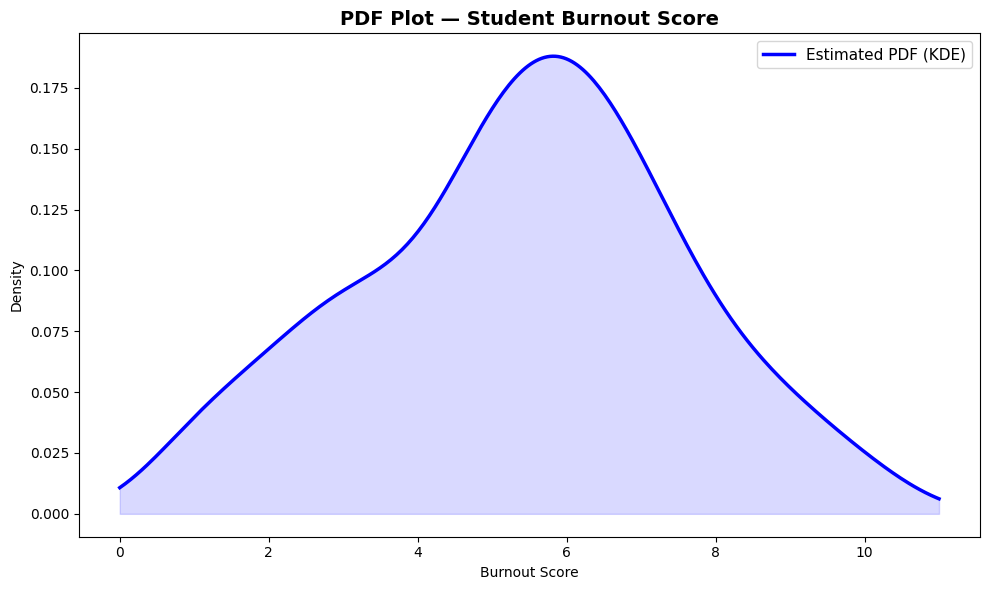

The blue curve shows the estimated shape of the burnout score distribution.
A perfectly normal distribution would be a symmetric bell shape.
Our skewness is -0.1301 — very close to 0, nearly symmetric.


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

# Create smooth x range
x = np.linspace(sample.min() - 1, sample.max() + 1, 300)

# KDE — estimated probability density function
kde = stats.gaussian_kde(sample)

ax.plot(x, kde(x), color="blue", linewidth=2.5,
        label="Estimated PDF (KDE)")
ax.fill_between(x, kde(x), alpha=0.15, color="blue")

ax.set_title("PDF Plot — Student Burnout Score",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Burnout Score")
ax.set_ylabel("Density")
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("The blue curve shows the estimated shape of the burnout score distribution.")
print("A perfectly normal distribution would be a symmetric bell shape.")
print(f"Our skewness is {stats.skew(sample):.4f} — very close to 0, nearly symmetric.")

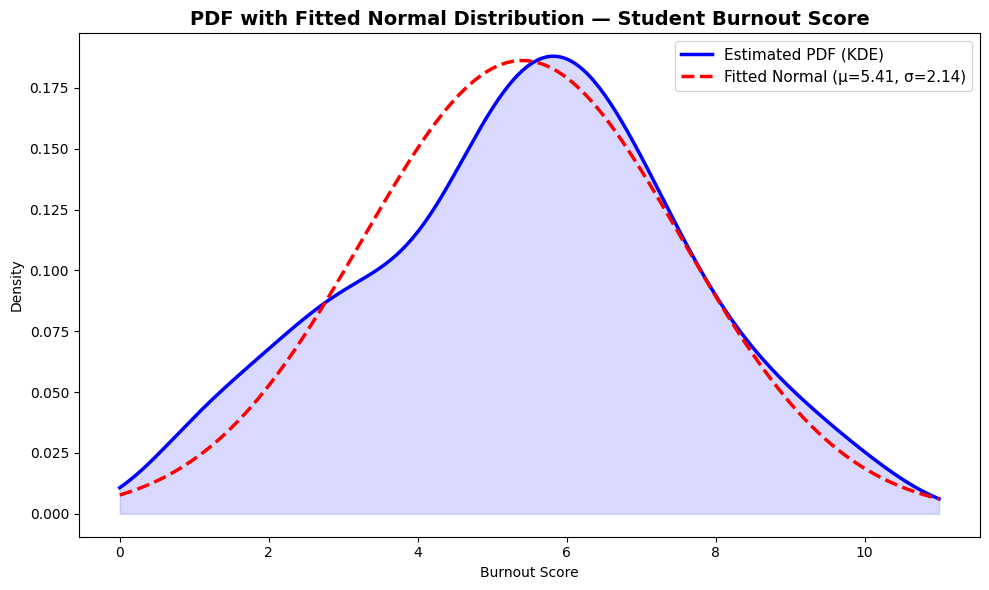

Fitted Normal — Mean (μ) : 5.4050
Fitted Normal — Std  (σ) : 2.1427

Goodness of Fit (KS Test):
  KS Statistic : 0.1244
  p-value      : 0.0037
  Result : Poor fit — data does not match the normal distribution


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

# Fit normal distribution to the sample
mu, std = norm.fit(sample)

# X range
x = np.linspace(sample.min() - 1, sample.max() + 1, 300)

# Blue KDE curve
kde = stats.gaussian_kde(sample)
ax.plot(x, kde(x), color="blue", linewidth=2.5,
        label="Estimated PDF (KDE)")
ax.fill_between(x, kde(x), alpha=0.15, color="blue")

# Red fitted normal curve
ax.plot(x, norm.pdf(x, mu, std), color="red", linewidth=2.5,
        linestyle="--", label=f"Fitted Normal (μ={mu:.2f}, σ={std:.2f})")

ax.set_title("PDF with Fitted Normal Distribution — Student Burnout Score",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Burnout Score")
ax.set_ylabel("Density")
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Goodness of fit — Kolmogorov-Smirnov test against fitted normal
ks_stat, ks_p = kstest(sample, "norm", args=(mu, std))

print(f"Fitted Normal — Mean (μ) : {mu:.4f}")
print(f"Fitted Normal — Std  (σ) : {std:.4f}")
print(f"\nGoodness of Fit (KS Test):")
print(f"  KS Statistic : {ks_stat:.4f}")
print(f"  p-value      : {ks_p:.4f}")
if ks_p > 0.05:
    print("  Result : Good fit — data matches the normal distribution")
else:
    print("  Result : Poor fit — data does not match the normal distribution")

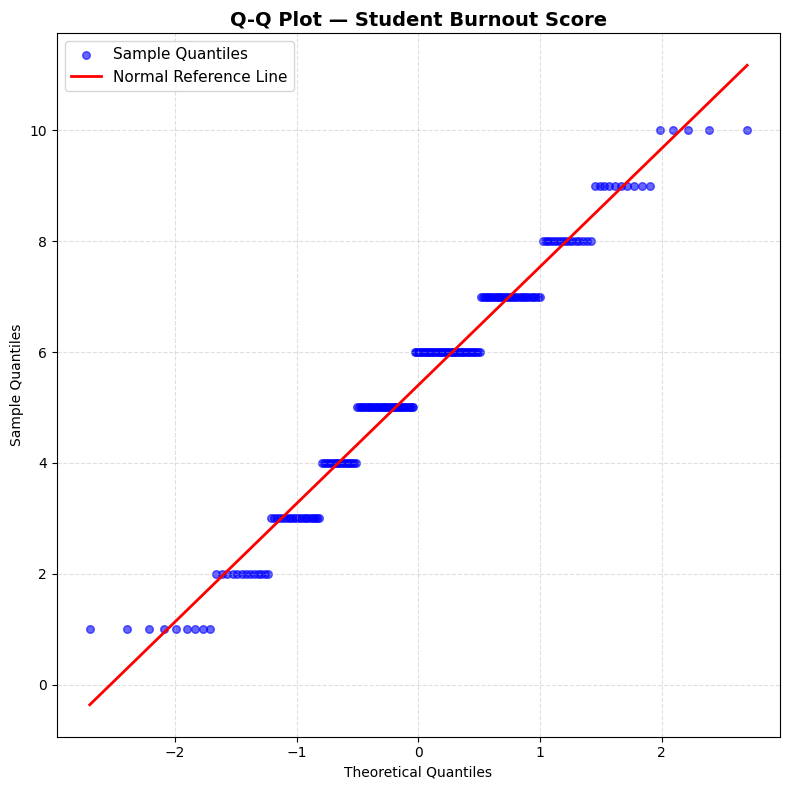

R-squared (correlation) : 0.9720

Interpretation:
  Dots closely following the red line = normally distributed
  Dots curving away from the line = deviation from normality
  R² = 0.9720 → Good fit, data is approximately normal


In [9]:
fig, ax = plt.subplots(figsize=(8, 8))

# Generate Q-Q plot
(osm, osr), (slope, intercept, r) = stats.probplot(sample, dist="norm")

# Plot the dots
ax.scatter(osm, osr, color="blue", alpha=0.6,
           s=30, label="Sample Quantiles")

# Plot the reference line
ax.plot(osm, slope * np.array(osm) + intercept,
        color="red", linewidth=2, label="Normal Reference Line")

ax.set_title("Q-Q Plot — Student Burnout Score",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Sample Quantiles")
ax.legend(fontsize=11)
ax.grid(axis="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

print(f"R-squared (correlation) : {r**2:.4f}")
print("\nInterpretation:")
print("  Dots closely following the red line = normally distributed")
print("  Dots curving away from the line = deviation from normality")
if r**2 > 0.98:
    print(f"  R² = {r**2:.4f} → Very strong fit, data is close to normal")
elif r**2 > 0.95:
    print(f"  R² = {r**2:.4f} → Good fit, data is approximately normal")
else:
    print(f"  R² = {r**2:.4f} → Moderate fit, some deviation from normality")

In [10]:
# ── Run all three tests ───────────────────────────────────────
# 1. Shapiro-Wilk
sw_stat, sw_p = shapiro(sample)

# 2. Kolmogorov-Smirnov
mu_fit, std_fit = norm.fit(sample)
ks_stat, ks_p = kstest(sample, "norm", args=(mu_fit, std_fit))

# 3. Anderson-Darling
ad_result = anderson(sample, dist="norm")
# Get p-value at 5% significance level (index 2)
ad_stat = ad_result.statistic
ad_critical = ad_result.critical_values[2]  # 5% level
ad_p = "< 0.05" if ad_stat > ad_critical else "> 0.05"

# ── Print summary table ───────────────────────────────────────
print("=" * 55)
print("NORMALITY TEST SUMMARY — Student Burnout Score")
print("=" * 55)
print(f"\n{'Test':<25} {'Statistic':>12} {'p-value':>12}")
print("-" * 55)
print(f"{'Shapiro-Wilk':<25} {sw_stat:>12.4f} {sw_p:>12.4f}")
print(f"{'Kolmogorov-Smirnov':<25} {ks_stat:>12.4f} {ks_p:>12.4f}")
print(f"{'Anderson-Darling':<25} {ad_stat:>12.4f} {ad_p:>12}")
print("-" * 55)
print("\nSignificance level : 0.05")
print("Rule               : p-value > 0.05 → Cannot reject normality")
print("                   : p-value < 0.05 → Reject normality")
print("\nIndividual results:")

if sw_p > 0.05:
    print(f"  Shapiro-Wilk      : p = {sw_p:.4f} → Cannot reject normality ✓")
else:
    print(f"  Shapiro-Wilk      : p = {sw_p:.4f} → Reject normality ✗")

if ks_p > 0.05:
    print(f"  Kolmogorov-Smirnov: p = {ks_p:.4f} → Cannot reject normality ✓")
else:
    print(f"  Kolmogorov-Smirnov: p = {ks_p:.4f} → Reject normality ✗")

if ad_stat < ad_critical:
    print(f"  Anderson-Darling  : stat = {ad_stat:.4f} < critical {ad_critical:.4f} → Cannot reject normality ✓")
else:
    print(f"  Anderson-Darling  : stat = {ad_stat:.4f} > critical {ad_critical:.4f} → Reject normality ✗")

NORMALITY TEST SUMMARY — Student Burnout Score

Test                         Statistic      p-value
-------------------------------------------------------
Shapiro-Wilk                    0.9682       0.0002
Kolmogorov-Smirnov              0.1244       0.0037
Anderson-Darling                2.3107       < 0.05
-------------------------------------------------------

Significance level : 0.05
Rule               : p-value > 0.05 → Cannot reject normality
                   : p-value < 0.05 → Reject normality

Individual results:
  Shapiro-Wilk      : p = 0.0002 → Reject normality ✗
  Kolmogorov-Smirnov: p = 0.0037 → Reject normality ✗
  Anderson-Darling  : stat = 2.3107 > critical 0.7720 → Reject normality ✗


In [11]:
print("=" * 55)
print("CONCLUSION")
print("=" * 55)
print("""
The normality analysis was performed on the burnout_score
column from the AI Dependency, Career Anxiety and Student
Burnout dataset (Kaggle, 2024). A random sample of 200
observations was used for the analysis.

Visually, the PDF plot showed a roughly bell-shaped curve
with a slight left skew (skewness = -0.1301). The fitted
normal distribution overlaid in red followed the blue KDE
curve reasonably well in the central region. The Q-Q plot
showed that the sample quantiles largely followed the
normal reference line, with an R-squared of 0.9720,
indicating a strong linear relationship.

However, all three formal normality tests rejected the
null hypothesis of normality at the 5% significance level:
Shapiro-Wilk (p = 0.0002), Kolmogorov-Smirnov (p = 0.0037),
and Anderson-Darling (statistic = 2.3107 > critical value).

The most likely explanation is that burnout_score is a
discrete integer scale from 1 to 10. Formal normality tests
are highly sensitive to discreteness and will reject
normality even when the overall shape closely resembles a
normal distribution. The Shapiro-Wilk statistic of 0.9682
is very close to 1.0, which confirms the data is nearly
normal in shape.

Conclusion: The burnout_score data cannot be considered
strictly normally distributed based on formal tests.
However, given the visual evidence and the near-normal
shape, it can be treated as approximately normal for
practical statistical purposes such as t-tests or ANOVA,
especially with a large sample size.
""")

CONCLUSION

The normality analysis was performed on the burnout_score
column from the AI Dependency, Career Anxiety and Student
Burnout dataset (Kaggle, 2024). A random sample of 200
observations was used for the analysis.

Visually, the PDF plot showed a roughly bell-shaped curve
with a slight left skew (skewness = -0.1301). The fitted
normal distribution overlaid in red followed the blue KDE
curve reasonably well in the central region. The Q-Q plot
showed that the sample quantiles largely followed the
normal reference line, with an R-squared of 0.9720,
indicating a strong linear relationship.

However, all three formal normality tests rejected the
null hypothesis of normality at the 5% significance level:
Shapiro-Wilk (p = 0.0002), Kolmogorov-Smirnov (p = 0.0037),
and Anderson-Darling (statistic = 2.3107 > critical value).

The most likely explanation is that burnout_score is a
discrete integer scale from 1 to 10. Formal normality tests
are highly sensitive to discreteness and will r